### White-noise transfer table (exp/white-cr.sh)

In [1]:
import json

import pandas as pd
from IPython.display import display

TAG = "white-cr"
COLS = ["C", "R", "EAR", "R1", "Rhalf"]
BOLD = {"C", "R", "EAR"}  # higher-is-better columns; the R split is diagnostic
TEX_HEAD = {"C": r"$C\uparrow$ (\%)", "R": r"$R\uparrow$ (\%)",
            "EAR": r"\textbf{EAR$_2$}$\uparrow$",
            "R1": r"$R_{=1}\uparrow$ (\%)", "Rhalf": r"$R_{=0.5}$ (\%)"}
DF_HEAD = {"C": "C (%)", "R": "R (%)", "EAR": "EAR",
           "R1": "R=1 (%)", "Rhalf": "R=0.5 (%)"}

# (group header or None for the ungrouped top block, rows); a group boundary is
# a \midrule + spanning header in LaTeX and the outer index level in pandas
BLOCKS = [
    (None, [
        dict(tex="Qwen2.5-Omni-3B", plain="Qwen2.5-Omni-3B", group="base",
             stem="white_Qwen2.5-Omni-3B"),
    ]),
    (r"\textit{Babble-tuned adapters (transfer)}", [
        dict(tex=r"\quad + SFT \textit{(sent2, restate prompt)}",
             plain="+ SFT (sent2, restate prompt)", group="babble (transfer)",
             stem="white_Qwen2.5-Omni-3B-bab-sent2-sft"),
        dict(tex=r"\quad + SFT \textit{(sent4, plain prompt)}",
             plain="+ SFT (sent4, plain prompt)", group="babble (transfer)",
             stem="white_Qwen2.5-Omni-3B-bab-sent4-sft"),
    ]),
    (r"\textit{In-domain reference}", [
        dict(tex=r"\quad + SFT \textit{(white noise, in-domain)}",
             plain="+ SFT (white noise, in-domain)", group="in-domain",
             stem="white_Qwen2.5-Omni-3B-ear-sft-adapter"),
    ]),
]

# --- load: C/R/EAR out of the trailing summary record, the R split out of its
# score_hist ("repair@<score>" -> n), which per-kind mode always writes ---
blocks = []
for header, block in BLOCKS:
    loaded = []
    for row in block:
        path = f"{row['stem']}_{TAG}.jsonl"
        summary = None
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                if "EAR" in rec:  # per-sample rows lack it
                    summary = rec
        if summary is None:
            raise ValueError(f"no summary line in {path}")
        hist, n = summary["score_hist"], summary["repair_rows"]
        loaded.append(dict(row, judge=summary["judge_model"], scores={
            "C": 100.0 * summary["C"],
            "R": 100.0 * summary["R"],
            "EAR": 100.0 * summary["EAR"],
            "R1": 100.0 * hist.get("repair@1", 0) / n,
            "Rhalf": 100.0 * hist.get("repair@0.5", 0) / n,
        }))
    blocks.append((header, loaded))

rows = [r for _, block in blocks for r in block]
best = {c: max(r["scores"][c] for r in rows) for c in BOLD}
judges = sorted({r["judge"] for r in rows})
if len(judges) > 1:
    raise ValueError(f"runs were judged by different models: {judges}")


def body(row):
    # bold the column winner across all four runs, higher-is-better columns only
    cells = []
    for c in COLS:
        cell = f"{row['scores'][c]:.1f}"
        cells.append(rf"\textbf{{{cell}}}"
                     if c in BOLD and row["scores"][c] == best[c] else cell)
    return rf"{row['tex']} & " + " & ".join(cells) + r" \\"


lines = [
    r"\begin{table}[t]",
    r"\centering",
    r"\begin{tabular}{l" + "c" * len(COLS) + "}",
    r"\toprule",
    r"\textbf{Model} & " + " & ".join(TEX_HEAD[c] for c in COLS) + r" \\",
]
for header, block in blocks:
    lines.append(r"\midrule")
    if header is not None:
        lines.append(rf"\multicolumn{{{len(COLS) + 1}}}{{c}}{{{header}}} \\")
        lines.append(r"\midrule")
    lines += [body(r) for r in block]
lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\caption{Transfer to unambiguous masking: the SLURP white-noise split "
    r"(100 test rows, 50 per kind) with one critical slot replaced by Gaussian "
    r"noise, scored by the per-kind judges (one direct 0/0.5/1 rubric per row "
    r"kind, the repair rubric told which piece was lost). We report task "
    r"competence on answerable inputs ($C$), repair behavior when one key piece "
    r"is lost ($R$), and their harmonic mean EAR$_2 = 2CR/(C+R)$; the split has "
    r"no \textit{repeat} rows, so EAR$_2$ is not comparable to EAR$_3$ "
    r"elsewhere. $R_{=1}$ and $R_{=0.5}$ are the share of repair rows scored 1 "
    r"(a question targeted at the lost piece) and 0.5 (an untargeted refusal "
    r"that merely avoids hallucinating); the base model earns most of its $R$ "
    r"from the latter. The babble-tuned adapters are evaluated with the prompt "
    rf"they were trained on. Judge: \texttt{{{judges[0]}}}.}}",
    r"\label{tab:white_cr}",
    r"\end{table}",
]

df = pd.DataFrame(
    [[round(r["scores"][c], 1) for c in COLS] for r in rows],
    index=pd.MultiIndex.from_tuples([(r["group"], r["plain"]) for r in rows]),
    columns=[DF_HEAD[c] for c in COLS],
)
display(df.style.set_caption(f"white-cr (judge: {judges[0]})").format("{:.1f}"))
print("\n".join(lines))

\begin{table}[t]
\centering
\begin{tabular}{lccccc}
\toprule
\textbf{Model} & $C\uparrow$ (\%) & $R\uparrow$ (\%) & \textbf{EAR$_2$}$\uparrow$ & $R_{=1}\uparrow$ (\%) & $R_{=0.5}$ (\%) \\
\midrule
Qwen2.5-Omni-3B & 76.0 & 26.0 & 38.7 & 6.0 & 40.0 \\
\midrule
\multicolumn{6}{c}{\textit{Babble-tuned adapters (transfer)}} \\
\midrule
\quad + SFT \textit{(sent2, restate prompt)} & \textbf{88.0} & 16.0 & 27.1 & 14.0 & 4.0 \\
\quad + SFT \textit{(sent4, plain prompt)} & 86.0 & 19.0 & 31.1 & 16.0 & 6.0 \\
\midrule
\multicolumn{6}{c}{\textit{In-domain reference}} \\
\midrule
\quad + SFT \textit{(white noise, in-domain)} & 86.0 & \textbf{81.0} & \textbf{83.4} & 76.0 & 10.0 \\
\bottomrule
\end{tabular}
\caption{Transfer to unambiguous masking: the SLURP white-noise split (100 test rows, 50 per kind) with one critical slot replaced by Gaussian noise, scored by the per-kind judges (one direct 0/0.5/1 rubric per row kind, the repair rubric told which piece was lost). We report task competence on an

### CRF tables for sent-based key pieces runs

In [1]:
# Two CRF tables for the sent-loss runs, one per judge -- scores are only
# comparable within a judge, never across them:
#   per-kind judge (no filename suffix) -- three direct 0/0.5/1 rubrics picked
#       by the row's own kind; the repair rubric is shown the lost piece.
#   tree judge ("-typejudge")           -- RESPONSE_TYPE_SYSTEM classifies the
#       reply's form, REPAIR_ON_TARGET_SYSTEM splits repair/repair_off, and
#       SCORE_MATRICES["tree"] converts the type to a score. A confident answer
#       on a repair/repeat row earns 1.0 here and 0 under the per-kind judge.
# Each table holds the same four runs: base model on the sent2 and sent4 splits
# on top, the two matching SFT adapters below the group rule.
# Self-contained, so it does not depend on helpers defined in other cells.
import json

import pandas as pd
from IPython.display import display

METRICS = ["C", "R", "F", "EAR"]

BASE_ROWS = [
    dict(tex=r"Qwen2.5-Omni-3B \textit{(sent2)}", plain="base (sent2)",
         stem="bab_results_Qwen2.5-Omni-3B_sent2-v1"),
    dict(tex=r"Qwen2.5-Omni-3B \textit{(sent4)}", plain="base (sent4)",
         stem="bab_results_Qwen2.5-Omni-3B_sent4-v1"),
]
SFT_ROWS = [
    dict(tex=r"Qwen2.5-Omni-3B + SFT \textit{(sent2)}", plain="SFT (sent2)",
         stem="bab_results_Qwen2.5-Omni-3B-bab-sent2-sft_sent2-v1"),
    dict(tex=r"Qwen2.5-Omni-3B + SFT \textit{(sent4)}", plain="SFT (sent4)",
         stem="bab_results_Qwen2.5-Omni-3B-bab-sent4-sft_sent4-v1"),
]
GROUP_HEADER = r"Our Model (\textit{Tuning on SLURP data with babble})"

JUDGES = [
    dict(name="per-kind judge", suffix="", label="tab:sent_perkind",
         blurb="one direct 0/0.5/1 rubric per row kind, the repair rubric told "
               "which piece was lost"),
    dict(name="tree judge", suffix="-typejudge", label="tab:sent_tree",
         blurb="a two-stage response-type classifier whose type is converted by "
               "the tree score matrix"),
]


def load_scores(stem, suffix):
    """C/R/F/EAR out of the trailing summary record of one result file."""
    summary = None
    with open(f"{stem}{suffix}.jsonl", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "EAR" in rec:  # per-sample rows lack it
                summary = rec
    if summary is None:
        raise ValueError(f"no summary line in {stem}{suffix}.jsonl")
    return {m: float(summary[m]) for m in METRICS}


def build_table(judge):
    rows = [dict(r, scores=load_scores(r["stem"], judge["suffix"]))
            for r in BASE_ROWS + SFT_ROWS]
    best = {m: max(r["scores"][m] for r in rows) for m in METRICS}

    def body(row):
        # bold the column winner across all four runs in this table
        cells = []
        for m in METRICS:
            cell = f"{row['scores'][m] * 100:.1f}"
            cells.append(rf"\textbf{{{cell}}}" if row["scores"][m] == best[m] else cell)
        return rf"{row['tex']} & " + " & ".join(cells) + r" \\"

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\begin{tabular}{lcccc}",
        r"\toprule",
        r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\",
        r"\midrule",
        *[body(r) for r in rows[:len(BASE_ROWS)]],
        r"\midrule",
        rf"\multicolumn{{5}}{{c}}{{{GROUP_HEADER}}} \\",
        r"\midrule",
        *[body(r) for r in rows[len(BASE_ROWS):]],
        r"\bottomrule",
        r"\end{tabular}",
        rf"\caption{{Repair-aware evaluation on the sent-loss SLURP splits "
        rf"(150 test rows, 50 per kind), scored by the {judge['name']}: "
        rf"{judge['blurb']}. We report task competence on answerable inputs "
        r"($C$), repair behavior when one key piece is lost ($R$), full-repair "
        r"behavior when nothing heard can be trusted ($F$), and their harmonic "
        r"mean EAR$_3$. \textit{sent2} runs prompt the model to restate what it "
        r"heard, \textit{sent4} runs use the plain prompt. Scores are comparable "
        r"within a judge only.}",
        rf"\label{{{judge['label']}}}",
        r"\end{table}",
    ]
    df = pd.DataFrame([{m: round(r["scores"][m] * 100, 1) for m in METRICS} for r in rows],
                      index=[r["plain"] for r in rows])
    return "\n".join(lines), df


for judge in JUDGES:
    latex, df = build_table(judge)
    display(df.style.set_caption(judge["name"]).format("{:.1f}"))
    print(latex)
    print()

,C,R,F,EAR
base (sent2),74.0,27.0,8.0,17.1
base (sent4),74.0,17.0,1.0,2.8
SFT (sent2),82.0,51.0,60.0,61.9
SFT (sent4),78.0,60.0,62.0,65.8


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B \textit{(sent2)} & 74.0 & 27.0 & 8.0 & 17.1 \\
Qwen2.5-Omni-3B \textit{(sent4)} & 74.0 & 17.0 & 1.0 & 2.8 \\
\midrule
\multicolumn{5}{c}{Our Model (\textit{Tuning on SLURP data with babble})} \\
\midrule
Qwen2.5-Omni-3B + SFT \textit{(sent2)} & \textbf{82.0} & 51.0 & 60.0 & 61.9 \\
Qwen2.5-Omni-3B + SFT \textit{(sent4)} & 78.0 & \textbf{60.0} & \textbf{62.0} & \textbf{65.8} \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation on the sent-loss SLURP splits (150 test rows, 50 per kind), scored by the per-kind judge: one direct 0/0.5/1 rubric per row kind, the repair rubric told which piece was lost. We report task competence on answerable inputs ($C$), repair behavior when one key piece is lost ($R$), full-repair behavior when nothing heard can be trusted ($F$), and their harmonic mean EAR$_3$. \textit{sent2

,C,R,F,EAR
base (sent2),46.0,18.0,6.0,12.3
base (sent4),44.0,34.0,4.0,9.9
SFT (sent2),58.0,63.0,68.0,62.7
SFT (sent4),58.0,70.0,64.0,63.6


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B \textit{(sent2)} & 46.0 & 18.0 & 6.0 & 12.3 \\
Qwen2.5-Omni-3B \textit{(sent4)} & 44.0 & 34.0 & 4.0 & 9.9 \\
\midrule
\multicolumn{5}{c}{Our Model (\textit{Tuning on SLURP data with babble})} \\
\midrule
Qwen2.5-Omni-3B + SFT \textit{(sent2)} & \textbf{58.0} & 63.0 & \textbf{68.0} & 62.7 \\
Qwen2.5-Omni-3B + SFT \textit{(sent4)} & \textbf{58.0} & \textbf{70.0} & 64.0 & \textbf{63.6} \\
\bottomrule
\end{tabular}
\caption{Repair-aware evaluation on the sent-loss SLURP splits (150 test rows, 50 per kind), scored by the tree judge: a two-stage response-type classifier whose type is converted by the tree score matrix. We report task competence on answerable inputs ($C$), repair behavior when one key piece is lost ($R$), full-repair behavior when nothing heard can be trusted ($F$), and their harmonic mean EAR$_3$. \texti

In [2]:
# Judged-response-type confusion for the tree-judge (typejudge) runs, one table
# per split. Rows are the audio kind the dataset labeled, columns the type the
# tree judge assigned, and every cell reads base -> SFT, so one table shows
# where the adapter moved the mass. Only the tree judge has these: the per-kind
# judge scores directly and never names a type, so its files carry an empty
# `confusion`.
# `repair_off` fills on repair rows only -- the second-stage
# REPAIR_ON_TARGET_SYSTEM call fires just where the tree matrix scores
# repair_off below repair, which holds for the repair row alone.
# Self-contained, so it can be run without the cell above.
import json

import pandas as pd
from IPython.display import display

KINDS = ["answer", "repair", "repeat"]  # dataset row kinds (rows)
JUDGED = ["answer", "repair", "repair_off", "repeat", "bad"]  # judge types (cols)
COL_LABELS = {t: t.replace("_", "-") for t in JUDGED}

SPLITS = [
    dict(name="sent2", label="tab:sent2_confusion",
         base="bab_results_Qwen2.5-Omni-3B_sent2-v1-typejudge",
         sft="bab_results_Qwen2.5-Omni-3B-bab-sent2-sft_sent2-v1-typejudge"),
    dict(name="sent4", label="tab:sent4_confusion",
         base="bab_results_Qwen2.5-Omni-3B_sent4-v1-typejudge",
         sft="bab_results_Qwen2.5-Omni-3B-bab-sent4-sft_sent4-v1-typejudge"),
]


def load_confusion(stem):
    """(kind, judged type) -> count, from the trailing summary record."""
    summary = None
    with open(f"{stem}.jsonl", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "confusion" in rec:  # per-sample rows lack it
                summary = rec
    if summary is None:
        raise ValueError(f"no summary line in {stem}.jsonl")
    conf = summary["confusion"]
    if not conf:
        raise ValueError(f"{stem}.jsonl has an empty confusion (per-kind judge?)")
    return {(k, t): int(conf.get(f"{k}->{t}", 0)) for k in KINDS for t in JUDGED}


def build_table(split):
    base, sft = load_confusion(split["base"]), load_confusion(split["sft"])

    def cell(kind, judged, arrow):
        b, s = base[(kind, judged)], sft[(kind, judged)]
        return f"{b} {arrow} {s}"

    lines = [
        r"\begin{table}[t]",
        r"\centering",
        r"\begin{tabular}{l" + "c" * len(JUDGED) + "}",
        r"\toprule",
        r"\textbf{Audio kind} & "
        + " & ".join(rf"\textit{{{COL_LABELS[t]}}}" for t in JUDGED)
        + r" \\",
        r"\midrule",
    ]
    for kind in KINDS:
        cells = []
        for t in JUDGED:
            c = cell(kind, t, r"$\rightarrow$")
            # diagonal: the judged type the audio kind was supposed to elicit
            cells.append(rf"\textbf{{{c}}}" if t == kind else c)
        lines.append(rf"\textit{{{kind}}} & " + " & ".join(cells) + r" \\")
    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        rf"\caption{{Shift in judged response type on the \textit{{{split['name']}}} "
        r"split, base~$\rightarrow$~SFT (raw counts, 50 rows per audio kind). Rows "
        r"are the audio kind the data builder labeled, columns the type the tree "
        r"judge assigned to the reply; the bold diagonal is the behavior that kind "
        r"calls for. \textit{repair-off} is a clarification question aimed at "
        r"something other than the lost piece, and is only reachable from a "
        r"\textit{repair} row.}",
        rf"\label{{{split['label']}}}",
        r"\end{table}",
    ]
    df = pd.DataFrame([[cell(k, t, "→") for t in JUDGED] for k in KINDS],
                      index=KINDS, columns=[COL_LABELS[t] for t in JUDGED])
    df.index.name = f"{split['name']}: kind \\ judged"
    return "\n".join(lines), df


for split in SPLITS:
    latex, df = build_table(split)
    display(df)
    print(latex)
    print()

,answer,repair,repair-off,repeat,bad
sent2: kind \ judged,,,,,
answer,23 → 29,9 → 9,0 → 0,3 → 0,15 → 12
repair,7 → 15,1 → 10,4 → 3,2 → 13,36 → 9
repeat,1 → 4,6 → 5,0 → 0,2 → 30,41 → 11


\begin{table}[t]
\centering
\begin{tabular}{lccccc}
\toprule
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repair-off} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{23 $\rightarrow$ 29} & 9 $\rightarrow$ 9 & 0 $\rightarrow$ 0 & 3 $\rightarrow$ 0 & 15 $\rightarrow$ 12 \\
\textit{repair} & 7 $\rightarrow$ 15 & \textbf{1 $\rightarrow$ 10} & 4 $\rightarrow$ 3 & 2 $\rightarrow$ 13 & 36 $\rightarrow$ 9 \\
\textit{repeat} & 1 $\rightarrow$ 4 & 6 $\rightarrow$ 5 & 0 $\rightarrow$ 0 & \textbf{2 $\rightarrow$ 30} & 41 $\rightarrow$ 11 \\
\bottomrule
\end{tabular}
\caption{Shift in judged response type on the \textit{sent2} split, base~$\rightarrow$~SFT (raw counts, 50 rows per audio kind). Rows are the audio kind the data builder labeled, columns the type the tree judge assigned to the reply; the bold diagonal is the behavior that kind calls for. \textit{repair-off} is a clarification question aimed at something other than the lost piece, and is only 

,answer,repair,repair-off,repeat,bad
sent4: kind \ judged,,,,,
answer,22 → 29,5 → 4,0 → 0,2 → 3,21 → 14
repair,17 → 9,0 → 21,2 → 3,0 → 10,31 → 7
repeat,2 → 0,2 → 8,0 → 0,0 → 32,46 → 10


\begin{table}[t]
\centering
\begin{tabular}{lccccc}
\toprule
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repair-off} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{22 $\rightarrow$ 29} & 5 $\rightarrow$ 4 & 0 $\rightarrow$ 0 & 2 $\rightarrow$ 3 & 21 $\rightarrow$ 14 \\
\textit{repair} & 17 $\rightarrow$ 9 & \textbf{0 $\rightarrow$ 21} & 2 $\rightarrow$ 3 & 0 $\rightarrow$ 10 & 31 $\rightarrow$ 7 \\
\textit{repeat} & 2 $\rightarrow$ 0 & 2 $\rightarrow$ 8 & 0 $\rightarrow$ 0 & \textbf{0 $\rightarrow$ 32} & 46 $\rightarrow$ 10 \\
\bottomrule
\end{tabular}
\caption{Shift in judged response type on the \textit{sent4} split, base~$\rightarrow$~SFT (raw counts, 50 rows per audio kind). Rows are the audio kind the data builder labeled, columns the type the tree judge assigned to the reply; the bold diagonal is the behavior that kind calls for. \textit{repair-off} is a clarification question aimed at something other than the lost piece, and is only 

### C, R, F table + confusion matrix

In [3]:
# Build 2 combined LaTeX tables (one per model family): CRF scores and the
# confusion-matrix shift side by side in a single table float (two minipages),
# so a reader gets the whole base -> SFT story for a family in one row.
# Self-contained (re-defines the loaders) so it doesn't pick up the tuple-returning
# load_summary of the very first cell.
import json

# ---- EDIT THESE PATHS -------------------------------------------------------
FAMILIES = [
    dict(
        base_file="bab_results_Qwen2.5-Omni-3B_tree-v3-hedge.jsonl",
        sft_file="bab_results_Qwen2.5-Omni-3B-bab-tree-sft_tree-v3-hedge.jsonl",
        base_name="Qwen2.5-Omni-3B",
        sft_name="Qwen2.5-Omni-3B (SFT)",
        label="tab:slurp_qwen25",
    ),
    # dict(
    #     base_file="bab_results_Qwen3-Omni-30B-A3B-Instruct_v2.jsonl",
    #     sft_file="bab_results_Qwen3-Omni-30B-A3B-Instruct-bab-sft-adapter_v2.jsonl",
    #     base_name="Qwen3-Omni-30B-A3B",
    #     sft_name="Qwen3-Omni-30B-A3B (SFT)",
    #     label="tab:slurp_qwen3",
    # ),
]
# -----------------------------------------------------------------------------

METRICS = ["C", "R", "F", "EAR"]  # babble track has 4 metrics
KINDS = ["answer", "repair", "repeat"]  # dataset row kinds (confusion rows)
JUDGED = ["answer", "repair", "repeat", "bad"]  # judge output types (confusion cols)


def load_last(path, field):
    """Last JSONL record in `path` carrying `field` -- the summary line."""
    found = None
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if field in rec:  # per-sample rows lack it
                found = rec
    if found is None:
        raise ValueError(f"no summary line with {field!r} in {path}")
    return found


def load_scores(path):
    s = load_last(path, "EAR")
    return {m: float(s[m]) for m in METRICS}


def load_confusion(path):
    conf = load_last(path, "confusion")["confusion"]
    return {(k, t): int(conf.get(f"{k}->{t}", 0)) for k in KINDS for t in JUDGED}


def build_crf_table(base_name, sft_name, base_scores, sft_scores):
    best = {m: max(base_scores[m], sft_scores[m]) for m in METRICS}

    def fmt(scores, metric):
        val = scores[metric] * 100.0
        cell = f"{val:.1f}"
        if scores[metric] == best[metric]:
            cell = rf"\textbf{{{cell}}}"
        return cell

    lines = []
    lines.append(r"\begin{tabular}{lcccc}")
    lines.append(r"\toprule")
    lines.append(r"\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\")
    lines.append(r"\midrule")
    lines.append(rf"{base_name} & " + " & ".join(fmt(base_scores, m) for m in METRICS) + r" \\")
    lines.append(rf"{sft_name} & " + " & ".join(fmt(sft_scores, m) for m in METRICS) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_confusion_table(base_conf, sft_conf):
    def cell(kind, judged):
        b, s = base_conf[(kind, judged)], sft_conf[(kind, judged)]
        if kind == judged:  # diagonal: judged type matches the audio's kind
            return rf"\textbf{{{b}}} $\rightarrow$ \textbf{{{s}}}"
        return rf"{b} $\rightarrow$ {s}"

    lines = []
    lines.append(r"\begin{tabular}{l" + "c" * len(JUDGED) + "}")
    lines.append(r"\toprule")
    lines.append(
        r"\textbf{Audio kind} & "
        + " & ".join(rf"\textit{{{COL_LABELS[t]}}}" for t in JUDGED)
        + r" \\"
    )
    lines.append(r"\midrule")
    for kind in KINDS:
        cells = " & ".join(cell(kind, t) for t in JUDGED)
        lines.append(rf"\textit{{{kind}}} & {cells} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def build_family_table(fam):
    base_scores = load_scores(fam["base_file"])
    sft_scores = load_scores(fam["sft_file"])
    base_conf = load_confusion(fam["base_file"])
    sft_conf = load_confusion(fam["sft_file"])

    crf_tab = build_crf_table(fam["base_name"], fam["sft_name"], base_scores, sft_scores)
    conf_tab = build_confusion_table(base_conf, sft_conf)

    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(crf_tab)
    lines.append(r"\vspace{6pt}")
    lines.append(conf_tab)
    lines.append(
        rf"\caption{{{fam['base_name']} $\rightarrow$ {fam['sft_name']}: repair-aware "
        r"scores (top; $C$/$R$/$F$/EAR$_3$) and the "
        r"shift in judged response type (bottom; raw counts, base~$\rightarrow$~SFT).}"
    )
    lines.append(rf"\label{{{fam['label']}}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

for fam in FAMILIES:
    print(build_family_table(fam))
    print()


\begin{table}[t]
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Model} & $C\uparrow$ & $R\uparrow$ & $F\uparrow$ & \textbf{EAR$_3$}$\uparrow$ \\
\midrule
Qwen2.5-Omni-3B & \textbf{60.0} & 23.0 & 14.0 & 22.8 \\
Qwen2.5-Omni-3B (SFT) & 52.0 & \textbf{73.0} & \textbf{34.0} & \textbf{48.1} \\
\bottomrule
\end{tabular}
\vspace{6pt}
\begin{tabular}{lcccc}
\toprule
\textbf{Audio kind} & \textit{answer} & \textit{repair} & \textit{repeat} & \textit{bad} \\
\midrule
\textit{answer} & \textbf{30} $\rightarrow$ \textbf{26} & 5 $\rightarrow$ 15 & 2 $\rightarrow$ 2 & 13 $\rightarrow$ 7 \\
\textit{repair} & 4 $\rightarrow$ 12 & \textbf{6} $\rightarrow$ \textbf{23} & 3 $\rightarrow$ 3 & 31 $\rightarrow$ 8 \\
\textit{repeat} & 2 $\rightarrow$ 2 & 5 $\rightarrow$ 25 & \textbf{5} $\rightarrow$ \textbf{15} & 38 $\rightarrow$ 8 \\
\bottomrule
\end{tabular}
\caption{Qwen2.5-Omni-3B $\rightarrow$ Qwen2.5-Omni-3B (SFT): repair-aware scores (top; $C$/$R$/$F$/EAR$_3$) and the shift in judged response type 

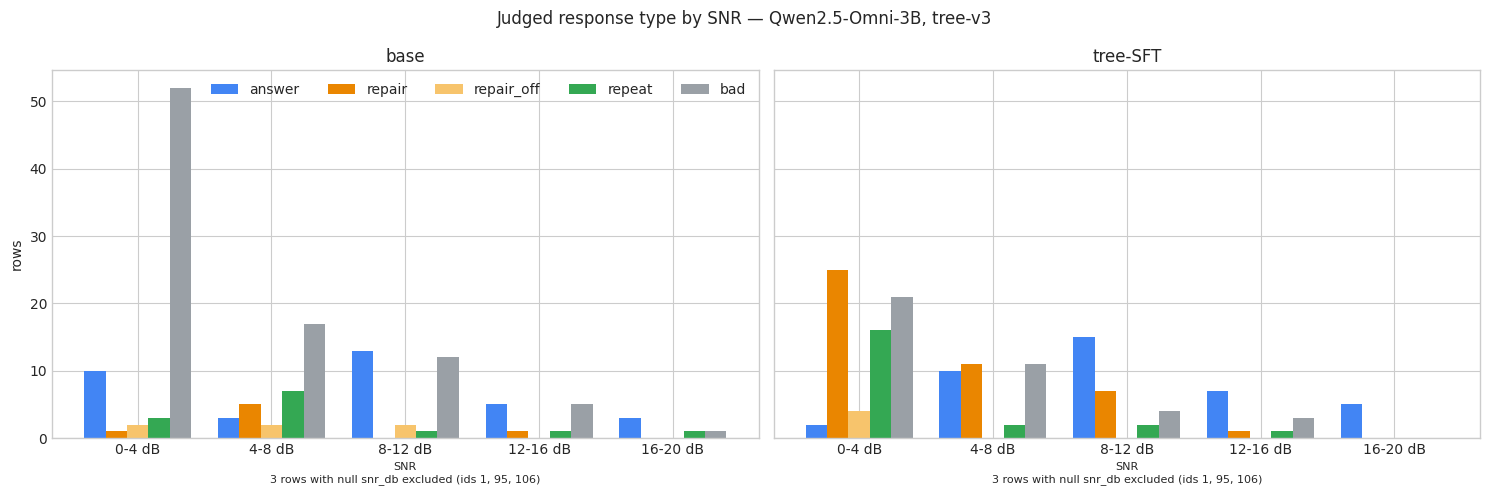

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

PAIR = [
    ("base", "bab_results_Qwen2.5-Omni-3B_tree-v3.jsonl"),
    ("tree-SFT", "bab_results_Qwen2.5-Omni-3B-bab-tree-sft_tree-v3.jsonl"),
]
EDGES = [0, 4, 8, 12, 16, 20]
BIN_LABELS = [f"{lo}-{hi} dB" for lo, hi in zip(EDGES[:-1], EDGES[1:])]
TYPES = ["answer", "repair", "repair_off", "repeat", "bad"]
COLORS = dict(zip(TYPES, ["#4285f4", "#ea8600", "#f7c46c", "#34a853", "#9aa0a6"]))

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, len(PAIR), figsize=(15, 5), sharey=True)
w = 0.8 / len(TYPES)

for ax, (name, path) in zip(axes, PAIR):
    rows = [json.loads(l) for l in open(path)]
    rows = [r for r in rows if r.get("type") != "summary"]
    dropped = [r["id"] for r in rows if r["snr_db"] is None]
    rows = [r for r in rows if r["snr_db"] is not None]
    # np.digitize with right=False puts snr==20 in an overflow bin; clip it back into the last bin
    idx = np.clip(np.digitize([r["snr_db"] for r in rows], EDGES) - 1, 0, len(BIN_LABELS) - 1)

    x = np.arange(len(BIN_LABELS))
    for j, t in enumerate(TYPES):
        counts = [sum(1 for b, r in zip(idx, rows) if b == i and r["judged_type"] == t)
                  for i in range(len(BIN_LABELS))]
        ax.bar(x + (j - (len(TYPES) - 1) / 2) * w, counts, w, label=t, color=COLORS[t])

    ax.set_xticks(x, BIN_LABELS)
    ax.set_title(name)
    ax.set_xlabel("SNR")
    if dropped:
        ax.set_xlabel(f"SNR\n{len(dropped)} rows with null snr_db excluded "
                      f"(ids {', '.join(map(str, dropped))})", fontsize=8)

axes[0].set_ylabel("rows")
axes[0].legend(ncol=len(TYPES), loc="upper right", frameon=False)
fig.suptitle("Judged response type by SNR — Qwen2.5-Omni-3B, tree-v3")
plt.tight_layout()
plt.show()
